# Class 24: Fourier Transforms Part 2

Ch. 7, section 4: Fast Fourier Transforms 

Complete the activities as instructed by the professor

#### Import any packages we need below (update as we go):

In [1]:
import numpy as np
from numpy import fft
import matplotlib.pyplot as plt
import time
import cmath
import random

### Fast Fourier Transforms 

**Super Simple Example:** Calculate FFT of a simple sawtooth example and then the inverse FFT

[ 4.5+0.j         -0.5+1.53884177j -0.5+0.68819096j -0.5+0.36327126j
 -0.5+0.16245985j -0.5+0.j        ]


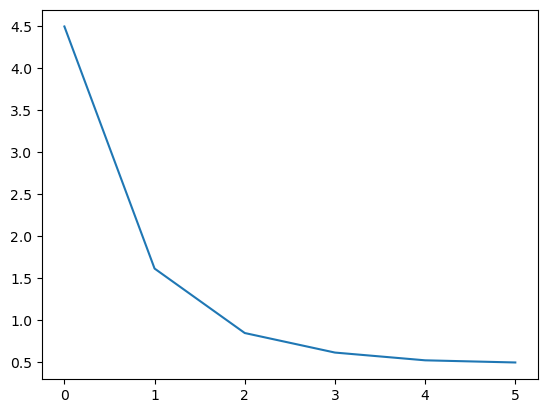

[-4.4408921e-17  1.0000000e-01  2.0000000e-01  3.0000000e-01
  4.0000000e-01  5.0000000e-01  6.0000000e-01  7.0000000e-01
  8.0000000e-01  9.0000000e-01]
[0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]


In [8]:

y = np.linspace(0,0.9,10)

c = fft.rfft(y) 

print(c) #note that this is now complex because the coefficients are always complex

plt.plot(np.abs(c))
plt.show()


z = fft.irfft(c) #inverse 
print(z)
print(y)


#### Discrete Fourier transform function from previous class

In [ ]:
def DFT(y): 
    # determine the number of sample points
    N = len(y)
    # create array for fourier coefficients 
    c = np.zeros(N//2+1, complex)
    # loop through to calculate coefficients 
    for k in range(N//2+1): 
        for n in range(N):
            c[k] += y[n]*cmath.exp(-2j*np.pi*k*n/N)
    return c

### Exercise 7.3: Fourier transforms of the sound of musical instruments

In the on-line resources you will find files called `piano.txt` and `trumpet.txt`, which contain data representing the waveform of a single note, played on, respectively, a piano and a trumpet.

**a)** Write a program that loads a waveform from one of these files, plots it, then calculates its discrete Fourier transform and plots the magnitudes of the first 10,000 coefficients in a manner similar to Fig. 7.3. Note that you will have to use a fast Fourier transform for the calculation because there are too many samples in the files to do the transforms the slow way in any reasonable amount of time.

Apply your program to the piano and trumpet waveforms and discuss briefly what one can conclude about the sound of the piano and trumpet from the plots of Fourier coefficients.

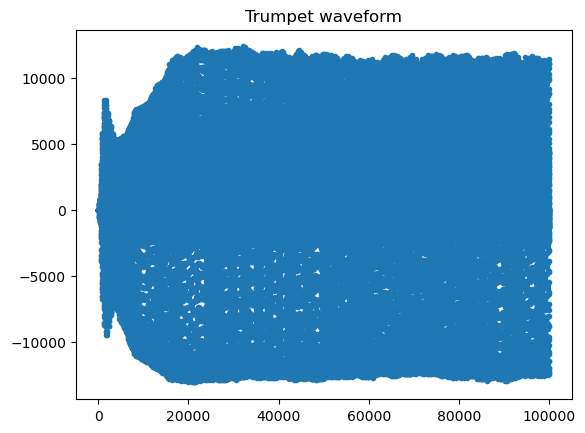

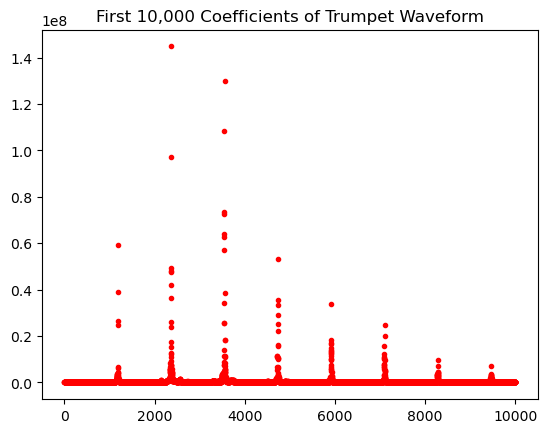

In [11]:

trumpet = np.loadtxt('trumpet.txt')

ctrumpet = fft.rfft(trumpet)

plt.plot(trumpet,'.')
plt.title('Trumpet waveform')
plt.show()

plt.plot(np.abs(ctrumpet[0:10000]),'r.')
plt.title('First 10,000 Coefficients of Trumpet Waveform')
plt.show()









**b)** Both waveforms were recorded at the industry-standard rate of 44,100 samples per second and both instruments were playing the same musical note when the recordings were made. From your Fourier transform results calculate what note they were playing. (Hint 1: the musical notes corresonds to the first peak int ehs pectrum, which is not necessarily the highest peak. Hint 2: The musical note middle C has a frequency of 261.6 Hz.)

In [14]:

#the frequency of the note depends on the k value at the first peak / fundamental

kt_fundamental = np.argmax(np.abs(ctrumpet[0:2000])) #returns the index of the highest peak (within the stipulated range)
#the index is our k because it corresponds to the frequency

#the frequency is usually k/N, but we have to multiply this by the sampling rate

srate = 44100

ftrumpet = kt_fundamental * srate / len(trumpet)

print('The frequency of the note played by the trumpet is',ftrumpet)

#521.703 is double the frequency of middle C, so an octave above middle C





The frequency of the note played by the trumpet is 521.703
